# Explorador visual con búsqueda en amplitud (BFS)
### Proyecto 1 — Fundamentos de Inteligencia Artificial
Universidad Tecnológica de la Huasteca Hidalguense

**Integrantes:**
- Iván — Matrícula: 20241110
- Isaí Pascual Cruz — Matrícula: 20241018


In [1]:
!pip install ipympl -q


## 1. Importaciones


In [2]:
%matplotlib widget
import json
import csv
import time
import random
from pathlib import Path
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.widgets import Button, Slider
from IPython.display import display
from google.colab import output
output.enable_custom_widget_manager()


## 2. Algoritmo BFS


In [3]:
DIRECCIONES = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # arriba, abajo, izquierda, derecha


def vecinos(grid, celda):
    """Devuelve las celdas libres adyacentes a 'celda' (sin diagonales)."""
    filas, columnas = len(grid), len(grid[0])
    f, c = celda
    for df, dc in DIRECCIONES:
        nf, nc = f + df, c + dc
        if 0 <= nf < filas and 0 <= nc < columnas and grid[nf][nc] == 0:
            yield (nf, nc)


def reconstruir_camino(parent, meta):
    """Sigue los padres desde la meta hasta el inicio y devuelve el camino."""
    camino = []
    actual = meta
    while actual is not None:
        camino.append(actual)
        actual = parent[actual]
    camino.reverse()
    return camino


def bfs(grid, inicio, meta, registrar_pasos=True):
    inicio, meta = tuple(inicio), tuple(meta)
    t0 = time.perf_counter()

    if grid[inicio[0]][inicio[1]] != 0 or grid[meta[0]][meta[1]] != 0:
        return {  # inicio o meta no transitables: fracaso inmediato
            "camino": None, "profundidad": None,
            "generados": 0, "expandidos": 0, "visitados": 0,
            "frontera_maxima": 0,
            "tiempo_ejecucion": time.perf_counter() - t0,
            "pasos": [],
        }

    frontera = deque([inicio])
    parent = {inicio: None}
    expandidos = 0
    frontera_maxima = len(frontera)
    pasos = []
    camino = None

    while frontera:
        estado = frontera.popleft()
        expandidos += 1
        es_meta = (estado == meta)

        if registrar_pasos:
            pasos.append({
                "expandido": estado,
                "frontera": list(frontera),
                "visitados": list(parent.keys()),
                "meta_encontrada": es_meta,
            })

        if es_meta:
            camino = reconstruir_camino(parent, meta)
            break

        for vecino in vecinos(grid, estado):
            if vecino in parent:
                continue  # ya alcanzado antes: no se agrega de nuevo
            parent[vecino] = estado
            frontera.append(vecino)

        frontera_maxima = max(frontera_maxima, len(frontera))

    return {
        "camino": camino,
        "profundidad": (len(camino) - 1) if camino else None,
        "generados": len(parent),
        "expandidos": expandidos,
        "visitados": len(parent),
        "frontera_maxima": frontera_maxima,
        "tiempo_ejecucion": time.perf_counter() - t0,
        "pasos": pasos,
    }


## 3. Generación y validación de mapas
Construcción de la semilla a partir de ambas matrículas, generación del
mapa principal

In [4]:
LIBRE = 0
OBSTACULO = 1


def construir_semilla(matricula_1: str, matricula_2: str) -> int:
    m1 = str(matricula_1).strip()
    m2 = str(matricula_2).strip()
    return int("".join(sorted([m1, m2])))


def _conectados_desde(grid, inicio):
    """Devuelve el conjunto de celdas libres alcanzables desde 'inicio'."""
    filas, columnas = len(grid), len(grid[0])
    visitados = {inicio}
    pila = [inicio]
    while pila:
        f, c = pila.pop()
        for df, dc in DIRECCIONES:
            nf, nc = f + df, c + dc
            vecino = (nf, nc)
            if 0 <= nf < filas and 0 <= nc < columnas and vecino not in visitados:
                if grid[nf][nc] == LIBRE:
                    visitados.add(vecino)
                    pila.append(vecino)
    return visitados


def _tiene_callejones(grid):
    """True si existe una celda libre con exactamente 1 vecino libre."""
    filas, columnas = len(grid), len(grid[0])
    for f in range(filas):
        for c in range(columnas):
            if grid[f][c] != LIBRE:
                continue
            libres = 0
            for df, dc in DIRECCIONES:
                nf, nc = f + df, c + dc
                if 0 <= nf < filas and 0 <= nc < columnas and grid[nf][nc] == LIBRE:
                    libres += 1
            if libres == 1:
                return True
    return False


def _generar_intento(rng, filas, columnas, pct_obstaculos, inicio, meta):
    """Coloca obstaculos al azar (con rng) dejando libres inicio y meta."""
    grid = [[LIBRE for _ in range(columnas)] for _ in range(filas)]
    total = filas * columnas
    n_obstaculos = int(total * pct_obstaculos)

    celdas = [(f, c) for f in range(filas) for c in range(columnas)
              if (f, c) not in (inicio, meta)]
    rng.shuffle(celdas)

    for (f, c) in celdas[:n_obstaculos]:
        grid[f][c] = OBSTACULO
    return grid


def generar_mapa(matricula_1, matricula_2, filas=25, columnas=25,
                  pct_obstaculos=0.28, longitud_minima=25, max_intentos=1000):
    if filas < 25 or columnas < 25:
        raise ValueError("El mapa debe tener al menos 25 filas y 25 columnas.")
    if not (0.20 <= pct_obstaculos <= 0.35):
        raise ValueError("El porcentaje de obstaculos debe estar entre 20% y 35%.")

    semilla_base = construir_semilla(matricula_1, matricula_2)
    inicio, meta = (0, 0), (filas - 1, columnas - 1)

    for intento in range(max_intentos):
        rng = random.Random(semilla_base + intento)
        grid = _generar_intento(rng, filas, columnas, pct_obstaculos, inicio, meta)

        if meta not in _conectados_desde(grid, inicio):
            continue

        resultado = bfs(grid, inicio, meta, registrar_pasos=False)
        if resultado["camino"] is None or resultado["profundidad"] < longitud_minima:
            continue

        if not _tiene_callejones(grid):
            continue

        return {
            "semilla": semilla_base,
            "intento": intento,
            "filas": filas,
            "columnas": columnas,
            "pct_obstaculos": pct_obstaculos,
            "inicio": list(inicio),
            "meta": list(meta),
            "grid": grid,
            "longitud_optima": resultado["profundidad"],
        }

    raise RuntimeError(
        f"No se logro generar un mapa valido tras {max_intentos} intentos; "
        "ajuste los parametros (tamano, % de obstaculos o longitud minima)."
    )


def generar_mapa_sencillo():
    filas, columnas = 7, 7
    grid = [[LIBRE for _ in range(columnas)] for _ in range(filas)]
    for f in range(filas):
        if f != 3:
            grid[f][3] = OBSTACULO
    inicio, meta = (0, 0), (6, 6)
    return {
        "semilla": None,
        "filas": filas,
        "columnas": columnas,
        "pct_obstaculos": None,
        "inicio": list(inicio),
        "meta": list(meta),
        "grid": grid,
        "descripcion": "Caso sencillo verificable a mano (ruta optima esperada: 12 movimientos)",
    }


def generar_mapa_estres(matricula_1, matricula_2, filas=30, columnas=30,
                         pct_obstaculos=0.35):
    """Mapa grande con el porcentaje maximo de obstaculos permitido."""
    return generar_mapa(
        matricula_1, matricula_2,
        filas=filas, columnas=columnas,
        pct_obstaculos=pct_obstaculos,
        longitud_minima=1,
    )


def guardar_mapa(mapa: dict, ruta: str):
    """Guarda un mapa como JSON, creando la carpeta destino si falta."""
    Path(ruta).parent.mkdir(parents=True, exist_ok=True)
    with open(ruta, "w", encoding="utf-8") as f:
        json.dump(mapa, f, ensure_ascii=False, indent=2)


def cargar_mapa(ruta: str) -> dict:
    """Lee un mapa guardado en JSON y lo devuelve como diccionario."""
    with open(ruta, "r", encoding="utf-8") as f:
        return json.load(f)


## 4. Semilla del equipo y generación de los 3 mapas
Con las mismas matrículas, esto siempre genera el mismo mapa principal

In [5]:
MATRICULA_1 = "20241110"  # IVAN
MATRICULA_2 = "20241018"  # ISAI PASCUAL CRUZ

CARPETA_MAPAS = Path("mapas")

print("Generando mapa principal (25x25, semilla de ambas matriculas)...")
mapa_principal = generar_mapa(MATRICULA_1, MATRICULA_2)
guardar_mapa(mapa_principal, str(CARPETA_MAPAS / "1_mapa_principal.json"))
print(f"  Semilla: {mapa_principal['semilla']}")
print(f"  Ruta optima: {mapa_principal['longitud_optima']} movimientos")

print("Generando mapa sencillo (verificable a mano)...")
mapa_sencillo = generar_mapa_sencillo()
guardar_mapa(mapa_sencillo, str(CARPETA_MAPAS / "2_mapa_sencillo.json"))
print(f"  {mapa_sencillo['descripcion']}")

print("Generando mapa de estres (35% de obstaculos)...")
mapa_estres = generar_mapa_estres(MATRICULA_1, MATRICULA_2)
guardar_mapa(mapa_estres, str(CARPETA_MAPAS / "3_mapa_estres.json"))
print(f"  Ruta optima: {mapa_estres['longitud_optima']} movimientos")

print(f"\nMapas guardados en: {CARPETA_MAPAS.resolve()}")


Generando mapa principal (25x25, semilla de ambas matriculas)...
  Semilla: 2024101820241110
  Ruta optima: 52 movimientos
Generando mapa sencillo (verificable a mano)...
  Caso sencillo verificable a mano (ruta optima esperada: 12 movimientos)
Generando mapa de estres (35% de obstaculos)...
  Ruta optima: 60 movimientos

Mapas guardados en: /tmp/claude-0/-home-claude/6cb51b2b-f5c9-57f2-9b1c-53ccacad9b3b/scratchpad/colab/fix_final/mapas


## 5. Pruebas por consola sobre los 3 mapas
Corre BFS sobre los tres mapas, guarda un resumen en `resultados/metricas.csv`
y compara la longitud calculada para el mapa sencillo contra el valor
esperado a mano (verificación real con `assert`, no solo un mensaje).

In [6]:
CARPETA_RESULTADOS = Path("resultados")
CARPETA_RESULTADOS.mkdir(parents=True, exist_ok=True)

CASOS = [
    ("Mapa principal", mapa_principal),
    ("Mapa sencillo", mapa_sencillo),
    ("Mapa de estres", mapa_estres),
]

RUTA_OPTIMA_ESPERADA_SENCILLO = 12  # calculada a mano: distancia Manhattan (0,0)->(6,6)

filas_csv = []
for nombre, mapa in CASOS:
    grid = mapa["grid"]
    inicio = tuple(mapa["inicio"])
    meta = tuple(mapa["meta"])

    resultado = bfs(grid, inicio, meta, registrar_pasos=False)

    print(f"\n=== {nombre} ===")
    print(f"Tamano: {len(grid)}x{len(grid[0])}  Inicio: {inicio}  Meta: {meta}")
    print(f"Solucion encontrada: {resultado['camino'] is not None}")
    print(f"Longitud del camino: {resultado['profundidad']}")
    print(f"Generados: {resultado['generados']}  Expandidos: {resultado['expandidos']}  "
          f"Visitados: {resultado['visitados']}  Frontera max.: {resultado['frontera_maxima']}")
    print(f"Tiempo: {resultado['tiempo_ejecucion']*1000:.3f} ms")

    filas_csv.append({
        "mapa": nombre,
        "filas": len(grid),
        "columnas": len(grid[0]),
        "solucion_encontrada": resultado["camino"] is not None,
        "longitud_camino": resultado["profundidad"],
        "nodos_generados": resultado["generados"],
        "nodos_expandidos": resultado["expandidos"],
        "estados_visitados": resultado["visitados"],
        "frontera_maxima": resultado["frontera_maxima"],
        "tiempo_ms": round(resultado["tiempo_ejecucion"] * 1000, 3),
    })

ruta_csv = CARPETA_RESULTADOS / "metricas.csv"
with open(ruta_csv, "w", newline="", encoding="utf-8") as f:
    escritor = csv.DictWriter(f, fieldnames=list(filas_csv[0].keys()))
    escritor.writeheader()
    escritor.writerows(filas_csv)
print(f"\nMetricas guardadas en: {ruta_csv.resolve()}")

resultado_sencillo = next(f for f in filas_csv if f["mapa"] == "Mapa sencillo")
obtenido = resultado_sencillo["longitud_camino"]
coincide = obtenido == RUTA_OPTIMA_ESPERADA_SENCILLO
print(f"\nVerificacion manual (mapa sencillo): esperado={RUTA_OPTIMA_ESPERADA_SENCILLO}, "
      f"obtenido={obtenido}, coincide={coincide}")
assert coincide, "La longitud calculada no coincide con la verificacion manual."



=== Mapa principal ===
Tamano: 25x25  Inicio: (0, 0)  Meta: (24, 24)
Solucion encontrada: True
Longitud del camino: 52
Generados: 440  Expandidos: 439  Visitados: 440  Frontera max.: 26
Tiempo: 0.542 ms

=== Mapa sencillo ===
Tamano: 7x7  Inicio: (0, 0)  Meta: (6, 6)
Solucion encontrada: True
Longitud del camino: 12
Generados: 43  Expandidos: 43  Visitados: 43  Frontera max.: 7
Tiempo: 0.055 ms

=== Mapa de estres ===
Tamano: 30x30  Inicio: (0, 0)  Meta: (29, 29)
Solucion encontrada: True
Longitud del camino: 60
Generados: 391  Expandidos: 390  Visitados: 391  Frontera max.: 17
Tiempo: 0.442 ms

Metricas guardadas en: /tmp/claude-0/-home-claude/6cb51b2b-f5c9-57f2-9b1c-53ccacad9b3b/scratchpad/colab/fix_final/resultados/metricas.csv

Verificacion manual (mapa sencillo): esperado=12, obtenido=12, coincide=True


## 6. Visualización
Los botones de esta sección son de `matplotlib` (`matplotlib.widgets.Button`),
no de `ipywidgets`. La animación la controla `FuncAnimation`, con su propio
temporizador, así que Iniciar/Pausar solo llaman a `anim.resume()` /
`anim.pause()` — nada de hilos, nada de `Play` escondido, nada de `jslink`.

In [7]:
COLORES = {
    "obstaculo": "#201F1F",
    "libre": "#fefefe",
    "inicio": "#05fb11",
    "meta": "#ff0404",
    "actual": "#fb8c00",
    "frontera": "#fff177",
    "visitado": "#1e94f5",
    "camino": "#8e24aa",
}
MAX_FRONTERA_MOSTRADA = 12


def _hex_a_rgb(hexcolor):
    hexcolor = hexcolor.lstrip("#")
    return tuple(int(hexcolor[i:i + 2], 16) / 255 for i in (0, 2, 4))


_RGB = {clave: _hex_a_rgb(valor) for clave, valor in COLORES.items()}

_ETIQUETAS_LEYENDA = [
    ("obstaculo", "Obstáculo"), ("libre", "Celda libre"),
    ("inicio", "Inicio"), ("meta", "Meta"),
    ("actual", "Nodo actual"), ("frontera", "Frontera abierta"),
    ("visitado", "Estados visitados"), ("camino", "Camino final"),
]


def _formatear_frontera(frontera):
    visibles = frontera[:MAX_FRONTERA_MOSTRADA]
    trozos = [", ".join(f"({f},{c})" for f, c in visibles[i:i + 3])
              for i in range(0, len(visibles), 3)]
    texto = "\n".join(trozos) if trozos else "(vacía)"
    if len(frontera) > MAX_FRONTERA_MOSTRADA:
        texto += f"\n... (+{len(frontera) - MAX_FRONTERA_MOSTRADA} más)"
    texto += f"\nTamaño total: {len(frontera)}"
    return texto


class ReproductorBFS:
    """Visor de BFS con controles nativos de matplotlib (Button/Slider) y
    FuncAnimation para el auto-avance. No usa ipywidgets ni HTML propio."""

    def __init__(self, nombre_mapa, mapa, resultado, velocidad_inicial=150):
        self.nombre_mapa = nombre_mapa
        self.resultado = resultado
        self.pasos = resultado["pasos"]
        self.indice_paso = -1
        self.animando = False

        self.grid = mapa["grid"]
        self.inicio = tuple(mapa["inicio"])
        self.meta = tuple(mapa["meta"])
        self.filas, self.columnas = len(self.grid), len(self.grid[0])

        self._armar_figura()
        self._armar_controles(velocidad_inicial)

        # FuncAnimation llama a self._tic cada "interval" ms. Si self.animando
        # es False, _tic no hace nada: por eso podemos dejarla siempre
        # corriendo de fondo y solo pausar/reanudar con los botones. Se crea
        # ANTES de reiniciar() porque reiniciar() llama a pausar(), que la usa.
        self.anim = animation.FuncAnimation(
            self.fig, self._tic, interval=velocidad_inicial,
            cache_frame_data=False, blit=False,
        )
        self.anim.pause()

        self.reiniciar(None)
        display(self.fig.canvas)

    # ---------------------------------------------------------------
    # Interfaz
    # ---------------------------------------------------------------
    def _armar_figura(self):
        filas, columnas = self.filas, self.columnas
        self.fig = plt.figure(figsize=(9.5, 6.6))
        gs = self.fig.add_gridspec(1, 2, width_ratios=[2.3, 1], wspace=0.05,
                                    left=0.04, right=0.98, top=0.93, bottom=0.20)
        self.ax_mapa = self.fig.add_subplot(gs[0])
        self.ax_panel = self.fig.add_subplot(gs[1])
        self.ax_panel.axis("off")
        self.fig.suptitle(self.nombre_mapa, fontsize=12, fontweight="bold")

        self.ax_mapa.set_xlim(0, columnas)
        self.ax_mapa.set_ylim(0, filas)
        self.ax_mapa.invert_yaxis()
        self.ax_mapa.set_xticks(range(columnas + 1))
        self.ax_mapa.set_yticks(range(filas + 1))
        self.ax_mapa.set_xticklabels([])
        self.ax_mapa.set_yticklabels([])
        self.ax_mapa.grid(color="#d9d9d9", linewidth=0.6)
        self.ax_mapa.tick_params(length=0)
        self.ax_mapa.set_aspect("equal")
        for spine in self.ax_mapa.spines.values():
            spine.set_color("#999999")

        self.rects = [[None] * columnas for _ in range(filas)]
        for f in range(filas):
            for c in range(columnas):
                rect = plt.Rectangle((c, f), 1, 1, facecolor=_RGB["libre"], edgecolor="none")
                self.ax_mapa.add_patch(rect)
                self.rects[f][c] = rect

        y = 0.97
        self.ax_panel.text(0.02, y, "Leyenda", fontsize=11, fontweight="bold", va="top",
                            transform=self.ax_panel.transAxes)
        y -= 0.055
        for clave, texto in _ETIQUETAS_LEYENDA:
            self.ax_panel.add_patch(plt.Rectangle((0.03, y - 0.02), 0.05, 0.028,
                                                    transform=self.ax_panel.transAxes,
                                                    facecolor=COLORES[clave], edgecolor="#666666", linewidth=0.6))
            self.ax_panel.text(0.11, y - 0.006, texto, fontsize=9, va="top", transform=self.ax_panel.transAxes)
            y -= 0.042

        y -= 0.03
        self.ax_panel.text(0.02, y, "Frontera (orden FIFO)", fontsize=11, fontweight="bold", va="top",
                            transform=self.ax_panel.transAxes)
        y -= 0.045
        self.texto_frontera = self.ax_panel.text(0.02, y, "", fontsize=7.5, va="top",
                                                   family="monospace", transform=self.ax_panel.transAxes)
        y_paso = y - 0.24
        self.texto_paso = self.ax_panel.text(0.02, y_paso, "", fontsize=9, va="top",
                                              transform=self.ax_panel.transAxes)

        y_metricas = y_paso - 0.06
        self.ax_panel.text(0.02, y_metricas, "Métricas al finalizar", fontsize=11, fontweight="bold",
                            va="top", transform=self.ax_panel.transAxes)
        self.texto_metricas = self.ax_panel.text(0.02, y_metricas - 0.05,
                                                   "Ejecute la búsqueda para ver métricas.",
                                                   fontsize=8, va="top", transform=self.ax_panel.transAxes)

    def _armar_controles(self, velocidad_inicial):
        ax_iniciar = self.fig.add_axes([0.05, 0.06, 0.13, 0.06])
        ax_pausar = self.fig.add_axes([0.20, 0.06, 0.13, 0.06])
        ax_avanzar = self.fig.add_axes([0.35, 0.06, 0.13, 0.06])
        ax_reiniciar = self.fig.add_axes([0.50, 0.06, 0.13, 0.06])
        ax_velocidad = self.fig.add_axes([0.68, 0.075, 0.28, 0.03])

        self.btn_iniciar = Button(ax_iniciar, "Iniciar")
        self.btn_pausar = Button(ax_pausar, "Pausar")
        self.btn_avanzar = Button(ax_avanzar, "Avanzar")
        self.btn_reiniciar = Button(ax_reiniciar, "Reiniciar")
        self.slider_velocidad = Slider(ax_velocidad, "Velocidad (ms)", 10, 400,
                                        valinit=velocidad_inicial, valstep=10)

        self.btn_iniciar.on_clicked(self.iniciar)
        self.btn_pausar.on_clicked(self.pausar)
        self.btn_avanzar.on_clicked(self.avanzar_paso)
        self.btn_reiniciar.on_clicked(self.reiniciar)
        self.slider_velocidad.on_changed(self._al_cambiar_velocidad)

    def _al_cambiar_velocidad(self, val):
        self.anim.event_source.interval = val

    # ---------------------------------------------------------------
    # Control de la búsqueda
    # ---------------------------------------------------------------
    def iniciar(self, event):
        if not self.pasos or self.indice_paso >= len(self.pasos) - 1:
            return
        self.animando = True
        self.anim.resume()

    def pausar(self, event):
        self.animando = False
        self.anim.pause()

    def _tic(self, frame):
        """Llamado por FuncAnimation cada 'interval' ms. Si no se le dio
        Iniciar, no hace nada (self.animando es False)."""
        if self.animando:
            self._avanzar_interno()

    def avanzar_paso(self, event):
        self.pausar(None)
        self._avanzar_interno()

    def _avanzar_interno(self):
        if self.indice_paso >= len(self.pasos) - 1:
            self.pausar(None)
            return
        self.indice_paso += 1
        self._mostrar_paso(self.indice_paso)
        if self.indice_paso == len(self.pasos) - 1 or self.pasos[self.indice_paso]["meta_encontrada"]:
            self.pausar(None)
            self._mostrar_metricas_finales()

    def reiniciar(self, event):
        self.pausar(None)
        self.indice_paso = -1
        self.texto_metricas.set_text("Ejecute la búsqueda para ver métricas.")
        for f in range(self.filas):
            for c in range(self.columnas):
                celda = (f, c)
                color = _RGB["obstaculo"] if self.grid[f][c] == 1 else _RGB["libre"]
                if celda == self.inicio: color = _RGB["inicio"]
                elif celda == self.meta: color = _RGB["meta"]
                self.rects[f][c].set_facecolor(color)
        self.texto_frontera.set_text("")
        self.texto_paso.set_text(f"Paso: 0 / {len(self.pasos)}")
        self.fig.canvas.draw_idle()

    # ---------------------------------------------------------------
    # Dibujo
    # ---------------------------------------------------------------
    def _mostrar_paso(self, idx):
        paso = self.pasos[idx]
        visitados = set(paso["visitados"])
        frontera_set = set(paso["frontera"])
        actual = paso["expandido"]
        camino_final = set()
        if paso["meta_encontrada"] and self.resultado["camino"]:
            camino_final = set(self.resultado["camino"])

        for f in range(self.filas):
            for c in range(self.columnas):
                celda = (f, c)
                if self.grid[f][c] == 1:
                    color = _RGB["obstaculo"]
                elif celda in camino_final:
                    color = _RGB["camino"]
                elif celda == actual:
                    color = _RGB["actual"]
                elif celda in frontera_set:
                    color = _RGB["frontera"]
                elif celda in visitados:
                    color = _RGB["visitado"]
                else:
                    color = _RGB["libre"]
                if celda == self.inicio:
                    color = _RGB["inicio"]
                elif celda == self.meta:
                    color = _RGB["meta"]
                self.rects[f][c].set_facecolor(color)

        self.texto_frontera.set_text(_formatear_frontera(paso["frontera"]))
        self.texto_paso.set_text(f"Paso: {idx + 1} / {len(self.pasos)}")
        self.fig.canvas.draw_idle()

    def _mostrar_metricas_finales(self):
        r = self.resultado
        estado = "Solución encontrada" if r["camino"] else "Sin solución (frontera agotada)"
        self.texto_metricas.set_text(
            f"{estado}\n\n"
            f"Longitud del camino: {r['profundidad']}\n"
            f"Nodos generados: {r['generados']}\n"
            f"Nodos expandidos: {r['expandidos']}\n"
            f"Estados visitados: {r['visitados']}\n"
            f"Profundidad de la solución: {r['profundidad']}\n"
            f"Tamaño máximo de frontera: {r['frontera_maxima']}\n"
            f"Tiempo de ejecución: {r['tiempo_ejecucion']*1000:.3f} ms"
        )
        self.fig.canvas.draw_idle()


### 6.1 Animación - Mapa principal
Esta celda corre BFS con registro de pasos y reproduce la animación.

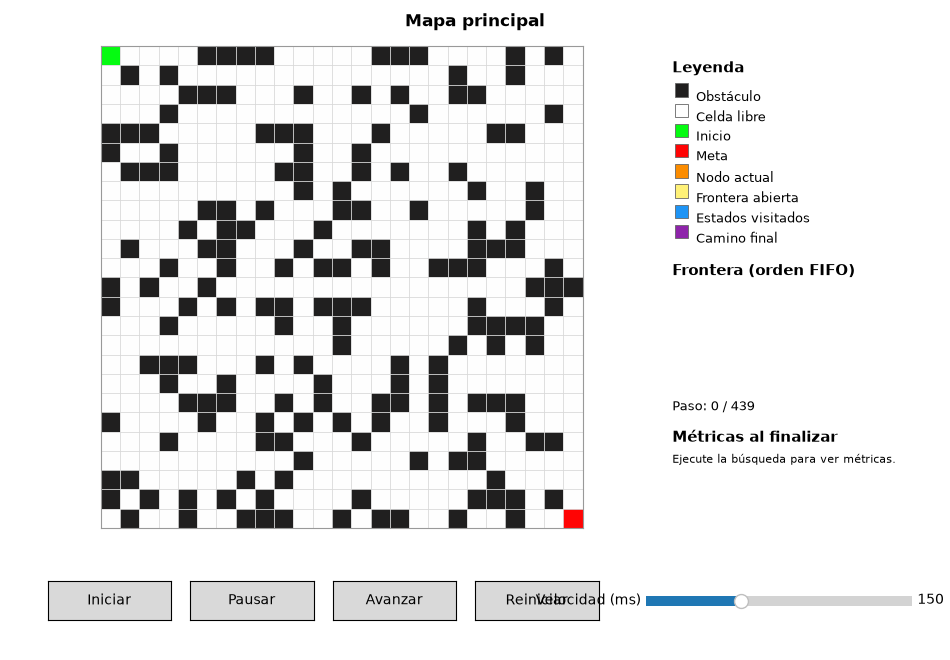

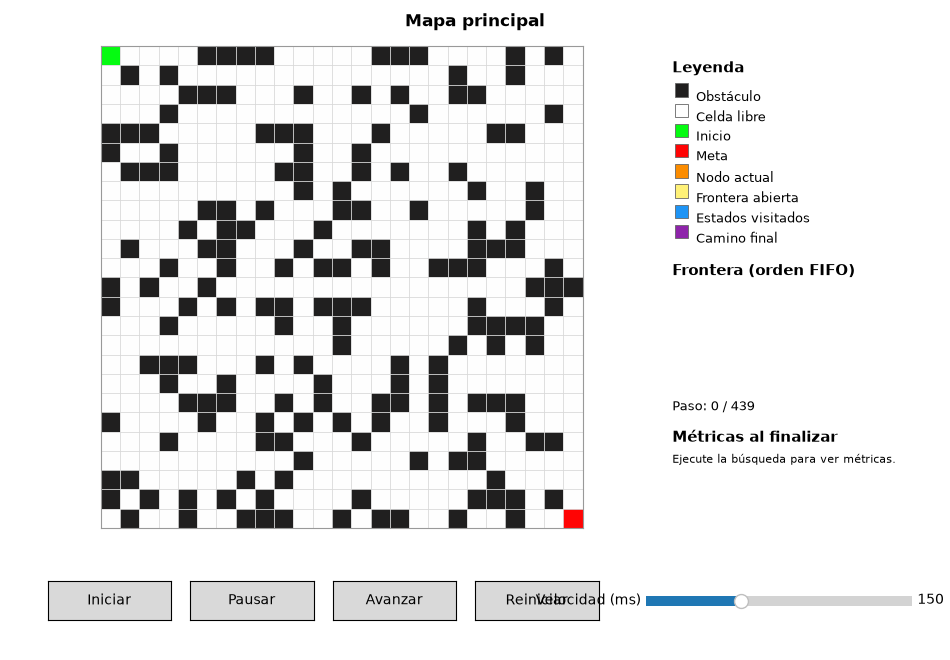

In [8]:
resultado_principal = bfs(mapa_principal["grid"], mapa_principal["inicio"], mapa_principal["meta"], registrar_pasos=True)
reproductor_principal = ReproductorBFS("Mapa principal", mapa_principal, resultado_principal)


### 6.2 Animación - Mapa sencillo

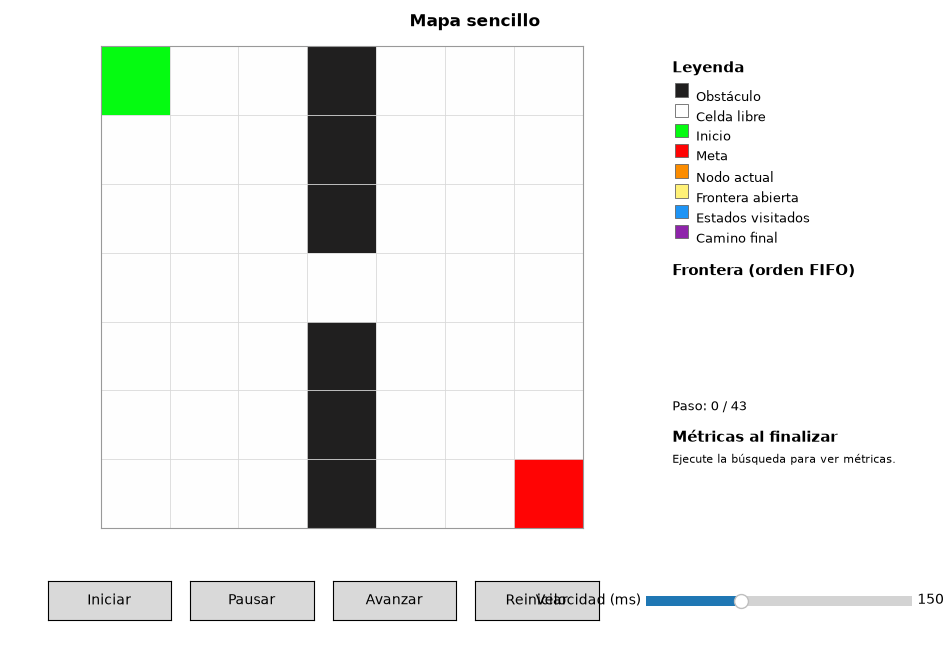

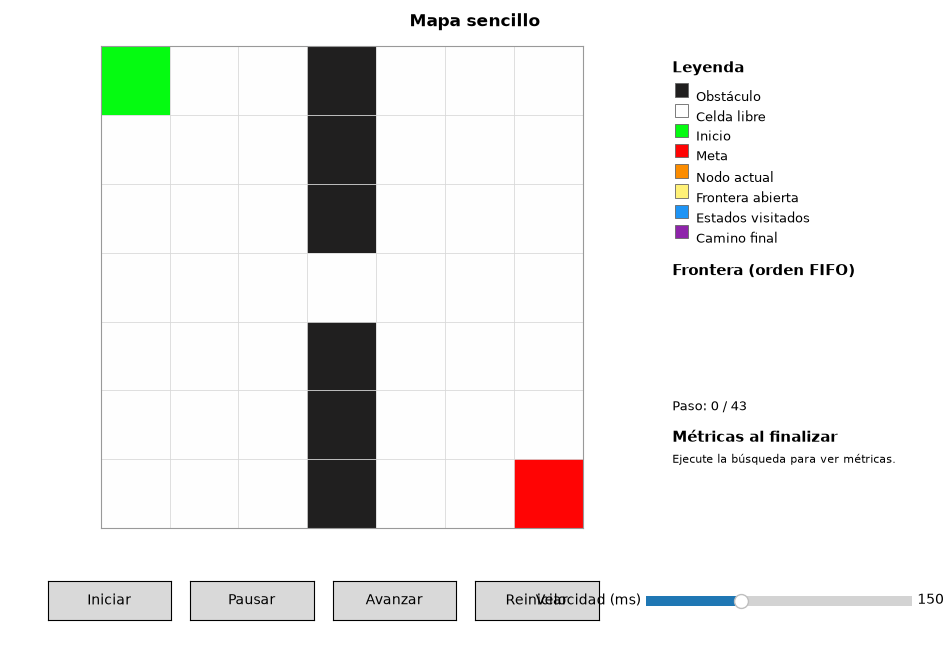

In [9]:
resultado_sencillo_anim = bfs(mapa_sencillo["grid"], mapa_sencillo["inicio"], mapa_sencillo["meta"], registrar_pasos=True)
reproductor_sencillo = ReproductorBFS("Mapa sencillo", mapa_sencillo, resultado_sencillo_anim)


### 6.3 Animación — Mapa de estrés

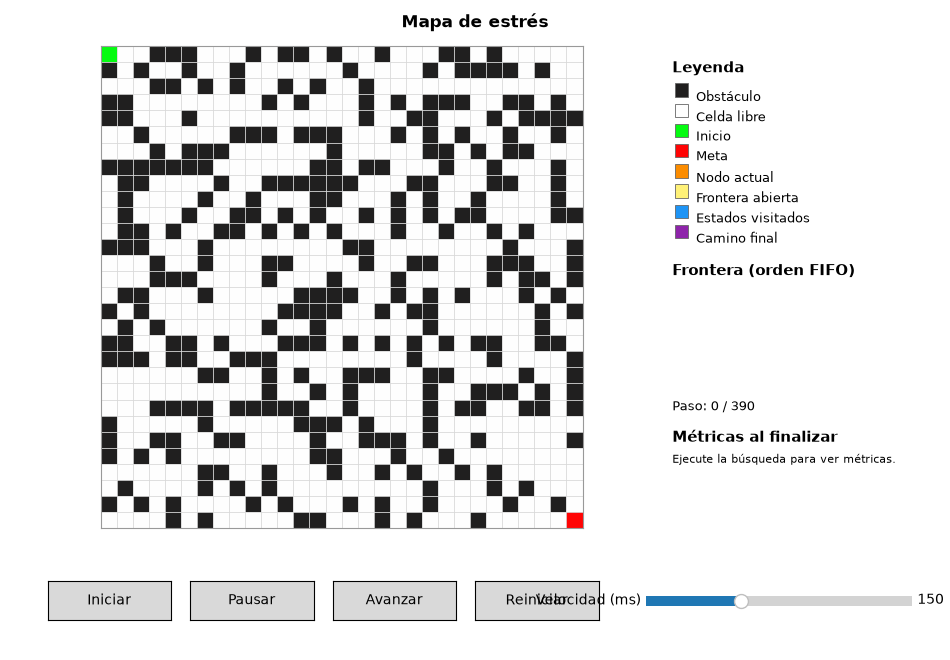

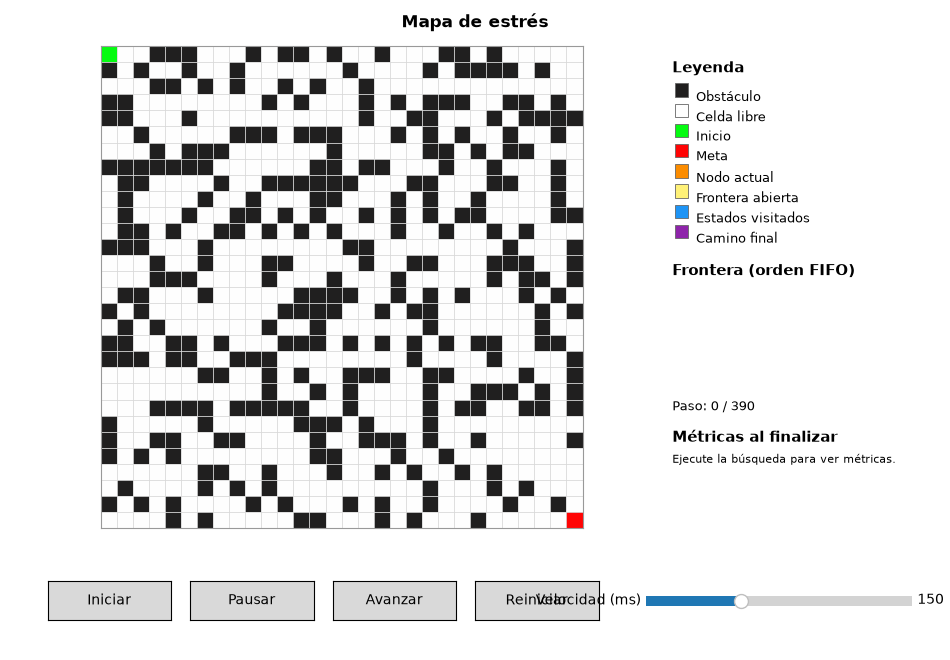

In [10]:
resultado_estres_anim = bfs(mapa_estres["grid"], mapa_estres["inicio"], mapa_estres["meta"], registrar_pasos=True)
reproductor_estres = ReproductorBFS("Mapa de estrés", mapa_estres, resultado_estres_anim)